## Visualize Mask

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

In [ ]:
input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

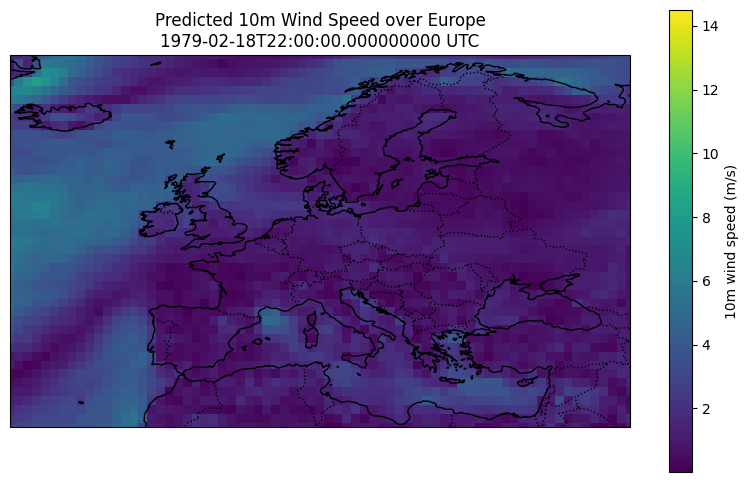

In [6]:
# Load prediction
pred = xr.open_dataset(climatology_path)

# Compute 10m wind speed
u10 = pred["10m_u_component_of_wind"]
v10 = pred["10m_v_component_of_wind"]
wind_speed = np.sqrt(u10**2 + v10**2)

# Select the time step closest to 22:00 UTC
selected_time = np.datetime64("2022-02-18T22:00")
wind = wind_speed.sel(time=selected_time, method="nearest")

# Create plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Define extent for Europe: [west, east, south, north]
ax.set_extent([-25, 45, 30, 72], crs=ccrs.PlateCarree())

# Plot wind speed
wind.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={"label": "10m wind speed (m/s)"})

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title(f"Predicted 10m Wind Speed over Europe\n{str(wind['time'].values)} UTC")

plt.show()

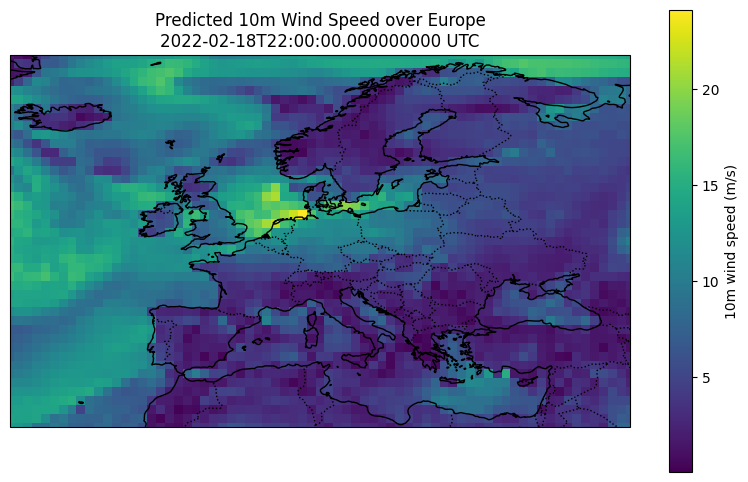

In [9]:
# Load prediction
pred = xr.open_dataset(input_path)

# Compute 10m wind speed
u10 = pred["10m_u_component_of_wind"]
v10 = pred["10m_v_component_of_wind"]
wind_speed = np.sqrt(u10**2 + v10**2)

# Select the time step closest to 22:00 UTC
selected_time = np.datetime64("2022-02-18T22:00")
wind = wind_speed.sel(time=selected_time, method="nearest")

# Create plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Define extent for Europe: [west, east, south, north]
ax.set_extent([-25, 45, 30, 72], crs=ccrs.PlateCarree())

# Plot wind speed
wind.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={"label": "10m wind speed (m/s)"})

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title(f"Predicted 10m Wind Speed over Europe\n{str(wind['time'].values)} UTC")

plt.show()